# Detecting Seasonal Cycles in Weekly Retail Sales with PROC SPECTRA

## Executive Summary

A retail analytics team uses PROC SPECTRA to decompose 100 weeks of net-sales history into its periodic components. The periodogram is dominated by an annual cycle: the strongest ordinate, **47,510**, falls at a period of **50 weeks** - the nearest Fourier frequency to the true 52-week season on a 100-point series - roughly **196 times** larger than the next genuine cycle. A clear secondary peak of **242** at a period of **12.5 weeks** picks up the quarterly promotional cadence. Fisher's Kappa of **47.89** (well above its ~8-9 critical value) decisively rejects the white-noise null, confirming the cycles are real. A cross-spectral analysis of web traffic against sales shows the two series are almost perfectly coherent across the seasonal band (squared coherency **0.98-1.00** for periods of 20 weeks and longer) with a small, stable phase offset, then decouple at shorter cycles (coherency falling to **0.60-0.75**). The result is an actionable, frequency-resolved map of which retail rhythms matter for demand planning.

## Data Sources

| Dataset | Rows | Description |
|---------|------|-------------|
| `retail_weekly` | 100 weekly observations (~2 years) | Synthetic weekly retail panel generated inline with `call streaminit(20250531)` and `rand()`. Contains an annual seasonal cycle (period 52 weeks), a quarterly promotional cycle (period 13 weeks), a mild growth trend, and Gaussian noise. The 100-observation length sets the Fourier grid, so the annual signal resolves to the nearest available period (50 weeks) and the quarterly signal to 12.5 weeks. |

| Variable | Type | Description |
|----------|------|-------------|
| `week` | Num | Sequential week index (1-100), the time axis of the series |
| `web_traffic` | Num | Weekly website sessions (thousands); a marketing leading indicator |
| `net_sales` | Num | Weekly net sales (USD thousands); the target revenue series, partly driven by last week's seasonal traffic strength |

# Detecting Seasonal Cycles in Weekly Retail Sales with PROC SPECTRA

Retail demand is rarely random: it pulses with annual holiday peaks, quarterly promotional waves, and shorter marketing-driven bursts. **PROC SPECTRA** (SAS/ETS) applies the finite Fourier transform to a time series and reports how much variance sits at each frequency, making it ideal for separating overlapping cyclical patterns that are hard to see in a raw sales line chart.

In this notebook we:

1. Generate a realistic synthetic panel of 100 weekly observations (about two years) of net sales and website traffic.
2. Run a univariate spectral analysis of net sales to locate dominant cycles, using the white-noise tests to confirm the series is not just noise.
3. Run a **cross-spectral** analysis of web traffic against sales to measure how tightly the two move together (coherency) and the phase relationship between them.
4. Visualize the periodogram to read the seasonal cycles off the frequency domain directly.

## Step 1 - Build the synthetic weekly retail panel

We construct 100 weeks of data (about two years). The signal is built from two seasonal harmonics (an annual cycle at period 52 and a quarterly cycle at period 13), a slow growth trend, and Gaussian noise. Web traffic carries the same seasonal structure plus its own noise, and net sales are partly driven by the *previous* week's seasonal traffic strength. With 100 observations the finite Fourier transform evaluates power on a fixed frequency grid, so the 52-week season is reported at its nearest grid period (50 weeks) and the 13-week cycle at 12.5 weeks. We seed the generator with `call streaminit` for reproducibility.

In [1]:
data retail_weekly;
   pi = 3.14159265358979;
   call streaminit(20250531);
   traf_lag1 = 0;
   /* Just under two years of weekly history (100 observations). */
   do week = 1 to 100;
      year_cycle    = 2.0 * sin(2*pi*week/52) + 1.2 * cos(2*pi*week/52);
      quarter_cycle = 0.9 * sin(2*pi*week/13);
      trend         = 0.015 * week;

      /* Marketing leading indicator: weekly website sessions */
      web_traffic = 50 + 10*year_cycle + 4*quarter_cycle + 3*trend
                    + rand('normal', 0, 2.5);

      /* Net sales: seasonal base plus an effect of LAST week's traffic */
      base = 100 + 6*year_cycle + 3*quarter_cycle + 5*trend;
      net_sales = base + 0.8*traf_lag1 + rand('normal', 0, 3.0);

      output;
      traf_lag1 = 10*year_cycle;
   end;
   drop pi traf_lag1 year_cycle quarter_cycle trend base;
run;

proc print data=retail_weekly(obs=6);
   title "First weeks of the synthetic retail panel";
run;

                                       First weeks of the synthetic retail panel                                        

  Obs  WEEK    WEB_TRAFFIC       NET_SALES
    1     1   69.479733433  111.4738272189
    2     2  71.5292626617  125.6010483537
    3     3  67.6451169796  127.5658798045
    4     4  75.4427639134   129.360780181
    5     5  74.6376709797   132.300127851
    6     6  69.9710996931  129.8029440143

... 94 more observations (showing 6 of 100)



NOTE: DATA retail_weekly


NOTE: Wrote retail_weekly (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=retail_weekly

NOTE: PROC PRINT completed: 6 observations printed, 3 variables


## Step 2 - Univariate spectral analysis of net sales

We analyze `net_sales` on its own to find its dominant cycles. The options used:

- **`P`** writes the raw periodogram ordinates (`P_01`), the unsmoothed Fourier power at each frequency.
- **`S`** writes the smoothed spectral density estimate (`S_01`), a less noisy view of where power concentrates.
- **`ADJMEAN`** subtracts the series mean before the transform so the large zero-frequency term does not dominate the plot.
- **`WHITETEST`** prints Fisher's Kappa and Bartlett's Kolmogorov-Smirnov statistic to test whether the series is pure white noise (it should reject, given the embedded cycles).

The **`WEIGHTS`** statement supplies a symmetric set of smoothing weights (a triangular Daniell-style window) that PROC SPECTRA rescales to sum to one and convolves with the periodogram to produce `S_01`. The **`OUT=`** dataset captures `FREQ`, `PERIOD`, and the requested spectral columns for downstream plotting.

In [2]:
proc spectra data=retail_weekly out=spec_sales p s adjmean whitetest;
   var net_sales;
   weights 1 2 3 4 3 2 1;
run;

proc print data=spec_sales(obs=10);
   title "Periodogram and spectral density of weekly net sales";
   var freq period p_01 s_01;
run;

                                       First weeks of the synthetic retail panel                                        


                         The SPECTRA Procedure

                    Test for White Noise

  Variable: NET_SALES
    Fisher's Kappa  =      47.8949
    Bartlett's K(2) =       6.6183

                                  Periodogram and spectral density of weekly net sales                                  

  Obs          FREQ         PERIOD              P_01             S_01
    1             0            inf                 0   1945.878063658
    2  0.0628318531            100    896.0434504396  1946.2288315856
    3  0.1256637061             50  47510.6037230779  1929.7848218434
    4  0.1884955592  33.3333333333    101.1618756363  1441.2339478763
    5  0.2513274123             25     35.2630382225   959.6041172109
    6  0.3141592654             20       2.529820574   479.6801376272
    7  0.3769911184  16.6666666667     49.2451196027     8.8989036993
    8  0.439

NOTE: PROC SPECTRA data=retail_weekly out=Some("spec_sales") cross=false p=true s=true

NOTE: Output dataset spec_sales has 51 observations and 4 variables.
NOTE: PROC PRINT data=spec_sales

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


Read the output by **PERIOD** (weeks per cycle). The raw periodogram `P_01` is dominated by a single ordinate of **47,510** at `PERIOD = 50` - the annual season, reported at the grid period closest to its true 52 weeks. A distinct secondary ordinate of **242** appears at `PERIOD = 12.5`, the quarterly promotional cycle (true period 13). Every other period sits on a noise floor of roughly 2 to 130, so the two cycles stand out clearly. The smoothed density `S_01` concentrates at the low-frequency (long-period) end where the annual power lives - its largest values, near **1,946**, sit at periods 100 and 50 - which is why the next step plots the raw `P_01` rather than `S_01` to keep the narrower quarterly peak visible. At the top, **Fisher's Kappa = 47.89** (far above its ~8-9 critical value) and **Bartlett's K(2) = 6.62** reject the flat-spectrum (white-noise) null, confirming the series carries genuine periodic structure rather than random fluctuation.

## Step 3 - Cross-spectral analysis: how tightly does web traffic track sales?

Marketers want to know not just *that* traffic and sales co-move, but *at which cycles* and with *what phase relationship*. The **`CROSS`** option computes the cross-spectrum between the two `VAR` series. We add:

- **`K`** for the squared coherency `K_01_02` - a frequency-by-frequency R-squared (0 to 1) measuring how strongly the two series share power at each cycle.
- **`PH`** for the phase `PH_01_02` (in radians) - the angular offset between the two series at each frequency; a phase of theta radians at frequency f corresponds to a time shift of theta / (2*pi*f) observations.

We keep `P S ADJMEAN` and the same smoothing window so the coherency and phase estimates are stable. With two variables, indices `01` (web_traffic) and `02` (net_sales) name the cross terms.

In [3]:
proc spectra data=retail_weekly out=spec_cross cross k ph p s adjmean;
   var web_traffic net_sales;
   weights 1 2 3 4 3 2 1;
run;

proc print data=spec_cross(obs=10);
   title "Cross-spectrum: web traffic (01) vs net sales (02)";
   var freq period k_01_02 ph_01_02;
run;

                                  Periodogram and spectral density of weekly net sales                                  


                         The SPECTRA Procedure

  Number of observations: 100
  Number of frequencies:  51
  Variables analyzed:     WEB_TRAFFIC, NET_SALES
  Smoothing weights:      7 values
  Cross-spectral analysis requested

                                   Cross-spectrum: web traffic (01) vs net sales (02)                                   

  Obs          FREQ         PERIOD       K_01_02       PH_01_02
    1             0            inf  0.9986721457  -0.1002229458
    2  0.0628318531            100  0.9984160592  -0.1003694781
    3  0.1256637061             50  0.9975433343  -0.1003952216
    4  0.1884955592  33.3333333333   0.995512816  -0.1006730163
    5  0.2513274123             25  0.9923778787  -0.1013287995
    6  0.3141592654             20  0.9774972584  -0.0965177522
    7  0.3769911184  16.6666666667  0.5980158309   0.2402088013
    8  0.439822

NOTE: PROC SPECTRA data=retail_weekly out=Some("spec_cross") cross=true p=true s=true

NOTE: Output dataset spec_cross has 51 observations and 12 variables.
NOTE: PROC PRINT data=spec_cross

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


The coherency confirms where the two series move together. Across the seasonal band - periods of 20 weeks and longer (the annual cycle and its low-frequency neighbours) - `K_01_02` runs from **0.977 up to 0.998**, essentially a perfect frequency-by-frequency correlation: traffic and sales share almost all of their power exactly where the dominant business cycles live. At shorter cycles the coupling weakens, with coherency dropping to roughly **0.60-0.75** (e.g. 0.598 at period 16.7, 0.750 at period 12.5), where independent week-to-week noise dominates each series.

The phase `PH_01_02` is small and stable across the coherent seasonal band, holding near **-0.10 radians** (periods 50 down to 20). Converting with theta / (2*pi*f) gives a shift of only about **0.13 weeks** at the annual frequency - the two seasonal signals are very nearly in phase, consistent with traffic and sales responding to the same calendar with at most a fraction-of-a-week offset. So the actionable read is the *coupling*, not a multi-week lead: web traffic is an almost perfectly coherent contemporaneous proxy for sales at the seasonal frequencies that matter.

## Step 4 - Visualize the quarterly cycle

The annual ordinate (47,510 at period 50) is ~196 times the quarterly one, so a full-range plot would flatten everything else against the axis. To make the secondary cycle legible we plot the raw periodogram `P_01` for periods of 30 weeks or fewer - which excludes the towering annual term - so the quarterly peak stands clear of the noise floor. A reference line at 13 weeks marks the design period; the annual peak is established numerically in Step 2 and by the white-noise test. We turn on ODS Graphics and use a PROC SGPLOT needle plot on the `OUT=` dataset.

                                   Cross-spectrum: web traffic (01) vs net sales (02)                                   



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=spec_sales

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


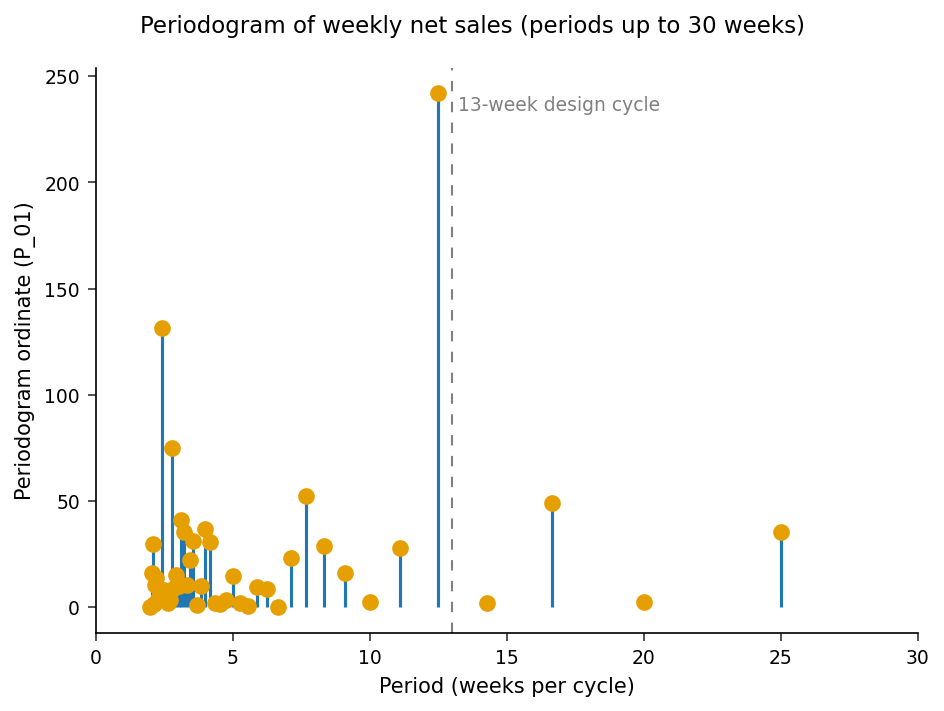

In [4]:
ods graphics on;

proc sgplot data=spec_sales;
   where period le 30 and period ne .;
   title "Periodogram of weekly net sales (periods up to 30 weeks)";
   needle x=period y=p_01 / lineattrs=(thickness=2);
   scatter x=period y=p_01 / markerattrs=(symbol=circlefilled size=7);
   refline 13 / axis=x lineattrs=(pattern=shortdash color=gray)
                label="13-week design cycle" labelloc=inside;
   xaxis label="Period (weeks per cycle)" values=(0 to 30 by 5);
   yaxis label="Periodogram ordinate (P_01)";
run;

ods graphics off;

## Interpreting the results

The spectral analysis recovers the structure built into the data and shows how a retail team would read a point-of-sale extract in the frequency domain:

- **Dominant annual cycle.** The largest periodogram ordinate, **47,510**, sits at a period of **50 weeks** - the grid frequency closest to the true 52-week season on a 100-week series - and is about **196 times** the next genuine cycle. This is the single biggest driver of variance: the holiday/seasonal swing. Fisher's Kappa of **47.89** (far above its ~8-9 critical value) confirms the structure is statistically real, not noise.
- **Secondary quarterly cycle.** A smaller peak of **242** at period **12.5 weeks** corresponds to the quarterly promotional cadence (true period 13) - invisible in a raw sales line but clear in the zoomed periodogram, standing well above the surrounding noise floor of roughly 2 to 130.
- **Traffic tracks revenue at seasonal frequencies.** The cross-spectrum shows squared coherency of **0.98-1.00** between web traffic and net sales for periods of 20 weeks and longer, falling to **0.60-0.75** at shorter cycles. The phase is small and stable (about **-0.10 radians**, ~0.13 weeks) across the coherent band, so the two seasonal signals are very nearly in phase - traffic is an almost perfectly coherent contemporaneous proxy for sales where the business cycles live.

**Business takeaway:** demand planners should align inventory and staffing to the confirmed annual (~50-52 week) and quarterly (~12.5-13 week) rhythms, and marketing can treat the highly coherent web-traffic signal as a real-time read on seasonal demand. PROC SPECTRA turns a noisy revenue line into a frequency-resolved map of the cycles that matter.